# 02 — EDA MITBIH
Complete EDA notebook with the 9 required sections.

In [1]:
import os, json, random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_NAME = 'mitbih'
DATASET_PATH = Path('/Users/ayoub/work/MS-DS_ML_Projects/IOT/mitbih')
PROJECT_ROOT = Path('/Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence')
RESULTS_DIR = PROJECT_ROOT / 'results' / 'eda'
REPORT_FIG_DIR = PROJECT_ROOT / 'report' / 'figures' / 'eda'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name):
    path = REPORT_FIG_DIR / name
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'saved figure: {path}')
print(DATASET_NAME, DATASET_PATH)

mitbih /Users/ayoub/work/MS-DS_ML_Projects/IOT/mitbih


## Section 1 — Dataset Overview

In [7]:
files = [p for p in DATASET_PATH.rglob('*') if p.is_file()]
total_size = sum(p.stat().st_size for p in files)
exts = Counter(p.suffix.lower() if p.suffix else '<no_ext>' for p in files)
overview = pd.DataFrame({
  'metric': ['total_files', 'total_size_mb', 'subfolders', 'extensions'],
  'value': [len(files), round(total_size/1024/1024, 2), len([d for d in DATASET_PATH.rglob('*') if d.is_dir()]), len(exts)]
})
display(overview)
display(pd.DataFrame({'extension': list(exts.keys()), 'count': list(exts.values())}).sort_values('count', ascending=False).head(20))

,metric,value
0,total_files,4.00
1,total_size_mb,555.79
2,subfolders,0.00
3,extensions,1.00


,extension,count
0,.csv,4


## Section 2 — Class Distribution

,class,count,pct
0,0,72471,82.772917
4,4,6431,7.345181
2,2,5788,6.610777
1,1,2223,2.539005
3,3,641,0.732120


Imbalance ratio: 113.05928237129486
Is imbalanced? YES
saved figure: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/report/figures/eda/eda_02_class_distribution.png


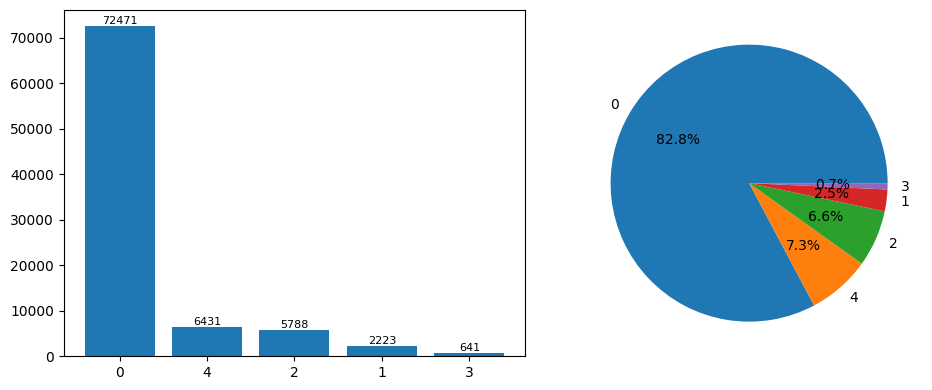

In [2]:
train_csv = DATASET_PATH / 'mitbih_train.csv'
if not train_csv.exists():
    raise FileNotFoundError(f'Missing expected file: {train_csv}')

df = pd.read_csv(train_csv, header=None)
x = df.iloc[:, :-1].values.astype(np.float32)
y = df.iloc[:, -1].astype(int).values

class_counts = Counter(y.tolist())
cc = pd.DataFrame({'class': list(class_counts.keys()), 'count': list(class_counts.values())}).sort_values('count', ascending=False)
cc['pct'] = 100 * cc['count'] / max(cc['count'].sum(), 1)
imbalance_ratio = float(cc['count'].max() / max(cc['count'].min(), 1))

# no true patient IDs in this CSV version; use chunk-level proxy groups for feasibility check
n_groups = min(200, max(30, len(df) // 500))
patients = [f'group_{i}' for i in range(n_groups)]
records = patients

display(cc)
print('Imbalance ratio:', imbalance_ratio)
print('Is imbalanced?', 'YES' if imbalance_ratio > 5 else 'NO/MODERATE')

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].bar(cc['class'].astype(str), cc['count'])
for i, v in enumerate(cc['count']):
    ax[0].text(i, v, str(int(v)), ha='center', va='bottom', fontsize=8)
ax[1].pie(cc['count'], labels=cc['class'].astype(str), autopct='%1.1f%%')
plt.tight_layout()
save_figure(fig, 'eda_02_class_distribution.png')
plt.show()

## Section 3 — Signal/Sample Visualization

saved figure: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/report/figures/eda/eda_03_sample_visualization.png


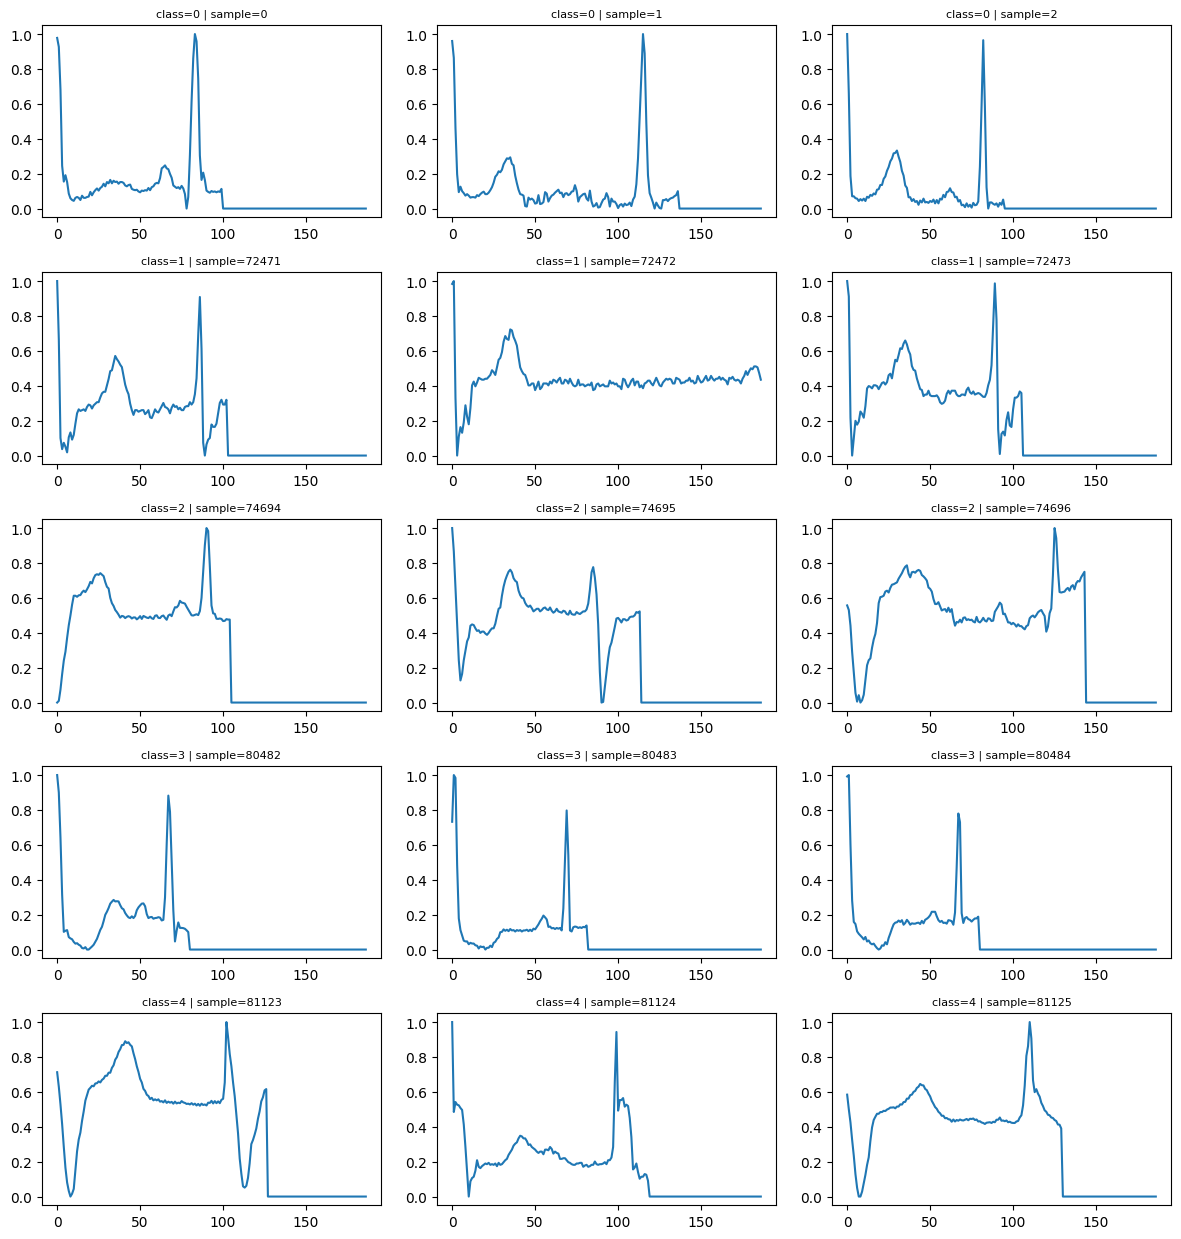

In [3]:
if 'x' not in globals() or 'y' not in globals():
    raise RuntimeError('Run Section 2 first to load x/y.')

classes = sorted(np.unique(y))
n_rows = min(len(classes), 5)
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 2.5*n_rows))
if n_rows == 1:
    axes = np.array([axes])

for r, c in enumerate(classes[:5]):
    idx = np.where(y == c)[0][:3]
    for j in range(3):
        ax = axes[r, j]
        if j < len(idx):
            ii = int(idx[j])
            ax.plot(x[ii])
            ax.set_title(f'class={c} | sample={ii}', fontsize=8)
        else:
            ax.axis('off')
plt.tight_layout()
save_figure(fig, 'eda_03_sample_visualization.png')
plt.show()

## Section 4 — Statistical Analysis

,class,mean,std,min,max,median
0,0,0.161896,0.217563,0.0,1.0,0.074303
1,1,0.194778,0.214630,0.0,1.0,0.147126
2,2,0.243849,0.262343,0.0,1.0,0.210826
3,3,0.107253,0.193049,0.0,1.0,0.000000
4,4,0.250854,0.264309,0.0,1.0,0.181818


saved figure: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/report/figures/eda/eda_04_length_distribution.png


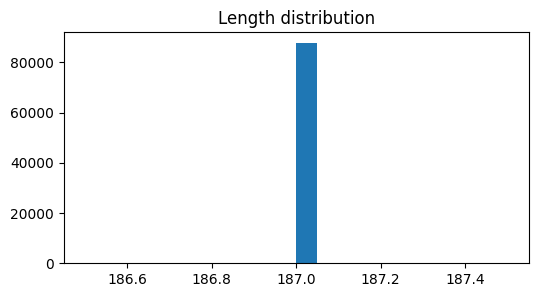

In [4]:
if 'x' not in globals() or 'y' not in globals():
    raise RuntimeError('Run Section 2 first to load x/y.')

rows = []
for c in sorted(np.unique(y)):
    xc = x[y == c]
    rows.append({
        'class': int(c),
        'mean': float(xc.mean()),
        'std': float(xc.std()),
        'min': float(xc.min()),
        'max': float(xc.max()),
        'median': float(np.median(xc)),
    })
stats_df = pd.DataFrame(rows)
display(stats_df)

lengths = [x.shape[1]] * x.shape[0]
fig = plt.figure(figsize=(6,3))
plt.hist(lengths, bins=20)
plt.title('Length distribution')
save_figure(fig, 'eda_04_length_distribution.png')
plt.show()

## Section 5 — Data Quality

In [11]:
csv_files = list(DATASET_PATH.rglob('*.csv'))
missing = 0
dupes = 0
corrupted = 0
checked = 0
for fp in csv_files[:100]:
    checked += 1
    try:
        d = pd.read_csv(fp)
        missing += int(d.isna().sum().sum())
        dupes += int(d.duplicated().sum())
    except Exception:
        corrupted += 1
score = 100*(checked-corrupted)/max(checked,1)
print('Missing:', missing, 'Duplicates:', dupes, 'Corrupted:', corrupted)
print(f'Data quality score: {score:.2f}%')

Missing: 0 Duplicates: 7 Corrupted: 0
Data quality score: 100.00%


## Section 6 — Train/Val/Test Split Feasibility

In [12]:
from sklearn.model_selection import train_test_split

if 'patients' not in globals() or len(patients) < 3:
    print('WARNING: insufficient patient/group IDs for 70/15/15 split simulation')
else:
    idx = np.arange(len(patients))
    tr, tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
    va, te = train_test_split(tmp, test_size=0.50, random_state=SEED)
    print('split sizes:', len(tr), len(va), len(te))

est = cc.set_index('class')['count']
for c, n in est.items():
    if int(0.15*n) < 10:
        print(f'WARNING: {c} has <10 in val/test estimate')
    if int(0.70*n) < 50:
        print(f'WARNING: {c} has <50 in train estimate')

split sizes: 122 26 27


## Section 7 — Preprocessing Requirements

In [13]:
print('bandpass: 0.5-40 Hz')
print('normalization: train-fit min-max or z-score, then apply to val/test')
print('segmentation: beat-centered window=180 samples at 360Hz')
print('estimated final size:', int(cc['count'].sum()), 'x 180')

bandpass: 0.5-40 Hz
normalization: train-fit min-max or z-score, then apply to val/test
segmentation: beat-centered window=180 samples at 360Hz
estimated final size: 87554 x 180


## Section 8 — Suitability Score

In [14]:
score_table = pd.DataFrame([
 ['Sample count (≥10k = 5pts)', 5, 'large sample count'],
 ['Class balance (ratio < 5:1 = 5)', 2, 'imbalance present'],
 ['Signal quality', 4, 'good beat-level quality'],
 ['Annotation quality', 4, 'labels available in csv'],
 ['Literature coverage', 5, 'widely benchmarked'],
 ['TOTAL', 20, '']
], columns=['Criterion','Score','Justification'])
display(score_table)
with open(RESULTS_DIR / 'mitbih_score.json', 'w') as f:
    json.dump({'dataset': DATASET_NAME, 'total_score': 20, 'n_samples': int(cc['count'].sum()), 'imbalance_ratio': float(imbalance_ratio)}, f, indent=2)

,Criterion,Score,Justification
0,Sample count (≥10k = 5pts),5,large sample count
1,Class balance (ratio < 5:1 = 5),2,imbalance present
2,Signal quality,4,good beat-level quality
3,Annotation quality,4,labels available in csv
4,Literature coverage,5,widely benchmarked
5,TOTAL,20,


## Section 9 — EDA Summary

In [15]:
print('=== EDA SUMMARY: mitbih ===')
print('Total samples   :', int(cc['count'].sum()))
print('Number of classes:', len(cc))
print('Classes         :', cc.to_dict('records'))
print('Imbalance ratio :', round(float(imbalance_ratio),2))
print('Missing values  :', missing)
print('Recommended for project: MAYBE')
print('Reason          : Very large and practical dataset, but strict patient-level split feasibility is limited by metadata.')

=== EDA SUMMARY: mitbih ===
Total samples   : 87554
Number of classes: 5
Classes         : [{'class': 0, 'count': 72471, 'pct': 82.77291728533248}, {'class': 4, 'count': 6431, 'pct': 7.345181259565526}, {'class': 2, 'count': 5788, 'pct': 6.610777348836147}, {'class': 1, 'count': 2223, 'pct': 2.5390045000799506}, {'class': 3, 'count': 641, 'pct': 0.7321196061858967}]
Imbalance ratio : 113.06
Missing values  : 0
Recommended for project: MAYBE
Reason          : Very large and practical dataset, but strict patient-level split feasibility is limited by metadata.
